# Exploratory Data Analysis - Customer Churn

Dataset: `data/raw/E Commerce Dataset.xlsx` (sheet `E Comm`).

Tujuan notebook ini: memahami struktur data mentah (jumlah baris/kolom, tipe data, missing value, distribusi target, dan hubungan fitur terhadap target) **sebelum** masuk ke tahap preprocessing (`src/preprocess.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent / "src"))
from config import DATA_DIR

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load Dataset

In [2]:
df = pd.read_excel(DATA_DIR / "E Commerce Dataset.xlsx", sheet_name="E Comm")
print("Shape:", df.shape)
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 2. Struktur & Tipe Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,NaN,NaN,NaN,52815.5,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,NaN,NaN,NaN,0.168384,0.37424,0.0,0.0,0.0,0.0,1.0
Tenure,5366.0,NaN,NaN,NaN,10.189899,8.557241,0.0,2.0,9.0,16.0,61.0
PreferredLoginDevice,5630,3,Mobile Phone,2765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,5630.0,NaN,NaN,NaN,1.654707,0.915389,1.0,1.0,1.0,3.0,3.0
WarehouseToHome,5379.0,NaN,NaN,NaN,15.639896,8.531475,5.0,9.0,14.0,20.0,127.0
PreferredPaymentMode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,5375.0,NaN,NaN,NaN,2.931535,0.721926,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5630.0,NaN,NaN,NaN,3.688988,1.023999,1.0,3.0,4.0,4.0,6.0


## 3. Missing Values

Beberapa kolom numerik punya nilai kosong -- ini yang nanti diimputasi dengan median pada `src/preprocess.py`.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0").sort_values(
    "missing_count", ascending=False
)

,missing_count,missing_pct
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


## 4. Distribusi Target (`Churn`)

Target imbalanced -- penting diperhatikan saat evaluasi model (precision/recall/F1, bukan hanya accuracy) dan saat split data (`stratify=Churn` di `src/preprocess.py`).

       count    pct
Churn              
0       4682  83.16
1        948  16.84


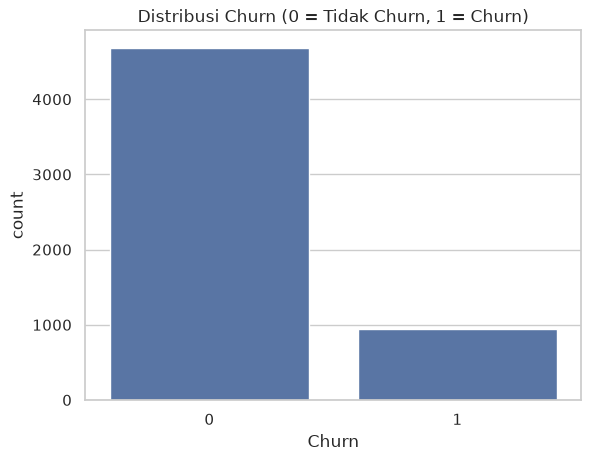

In [6]:
churn_counts = df["Churn"].value_counts()
churn_pct = (churn_counts / len(df) * 100).round(2)
print(pd.DataFrame({"count": churn_counts, "pct": churn_pct}))

sns.countplot(data=df, x="Churn")
plt.title("Distribusi Churn (0 = Tidak Churn, 1 = Churn)")
plt.show()

## 5. Distribusi Fitur Numerik

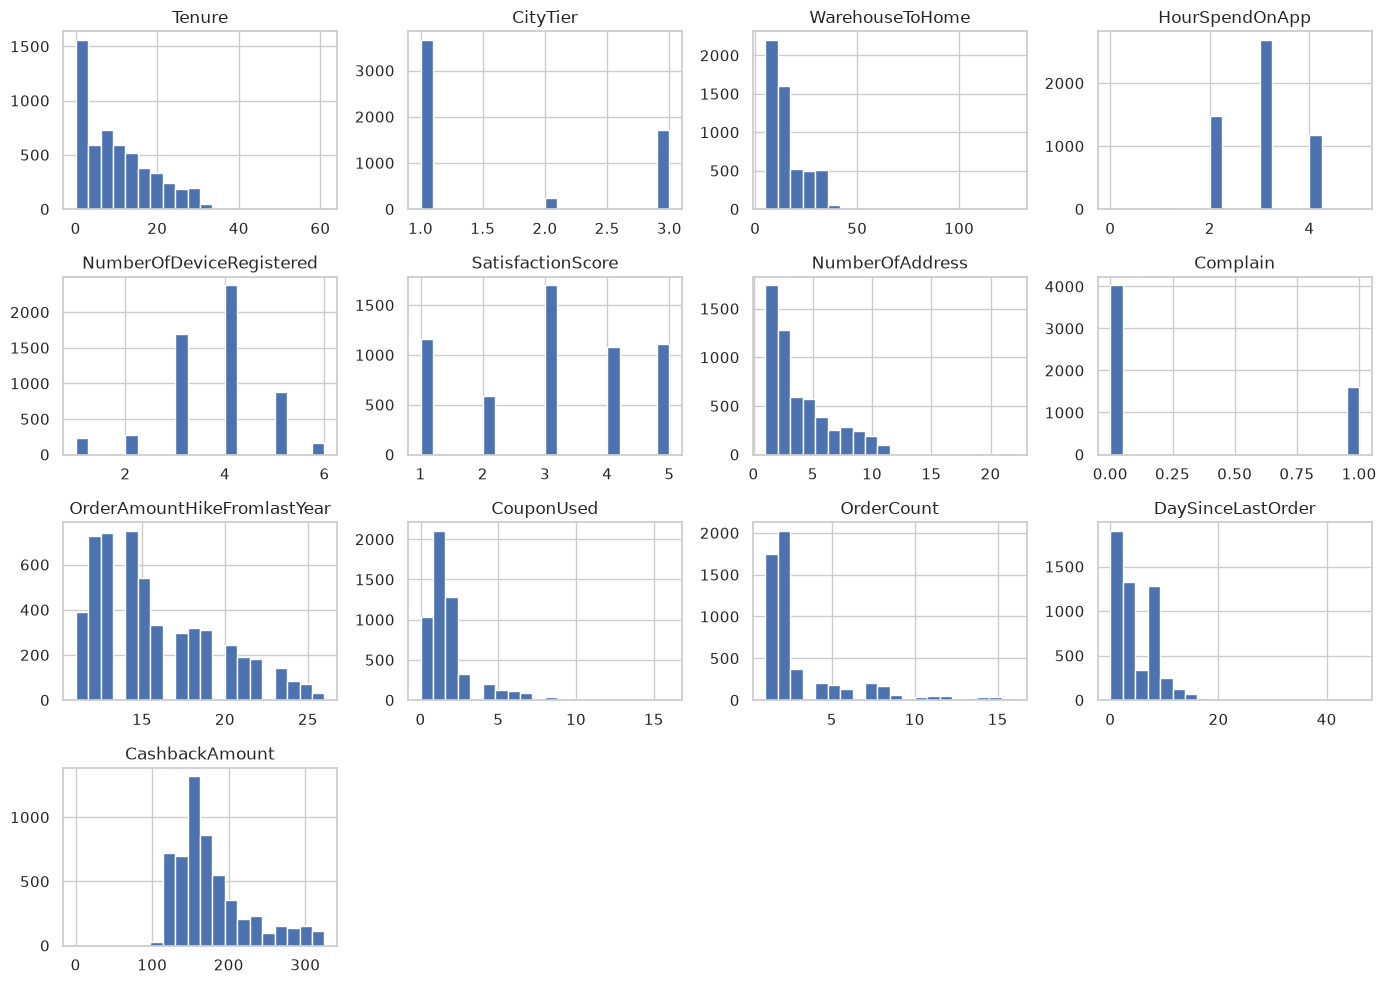

In [7]:
numeric_cols = df.select_dtypes(include="number").columns.drop(["CustomerID", "Churn"])

df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

## 6. Fitur Kategorikal

In [8]:
categorical_cols = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus",
]

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- PreferredLoginDevice ---
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

--- PreferredPaymentMode ---
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

--- Gender ---
Gender
Male      3384
Female    2246
Name: count, dtype: int64

--- PreferedOrderCat ---
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

--- MaritalStatus ---
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64



### 6.1 Temuan: Kategori Duplikat (Data Quality Issue)

Dari value counts di atas, ada kategori yang maknanya sama tapi ditulis berbeda:

- `PreferredPaymentMode`: **"CC"** (273 baris) vs **"Credit Card"** (1501 baris) -- sama-sama kartu kredit. Juga **"COD"** (365) vs **"Cash on Delivery"** (149).
- `PreferedOrderCat`: **"Mobile"** (809) vs **"Mobile Phone"** (1271) -- sama-sama kategori HP.

Kalau dibiarkan, one-hot encoding akan memecah kategori ini jadi kolom terpisah, sehingga sinyal fitur untuk prediksi churn jadi lemah (tersebar ke 2 kolom, bukan 1). Ini sudah ditangani di `src/preprocess.py` lewat `CATEGORY_NORMALIZATION_MAP` + fungsi `normalize_categories()`, dijalankan sebelum one-hot encoding.

In [9]:
from preprocess import normalize_categories

before = df["PreferredPaymentMode"].value_counts()
after = normalize_categories(df.copy())["PreferredPaymentMode"].value_counts()

print("Sebelum normalisasi:")
print(before)
print("\nSesudah normalisasi (CC -> Credit Card, COD -> Cash on Delivery):")
print(after)

Sebelum normalisasi:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Sesudah normalisasi (CC -> Credit Card, COD -> Cash on Delivery):
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64


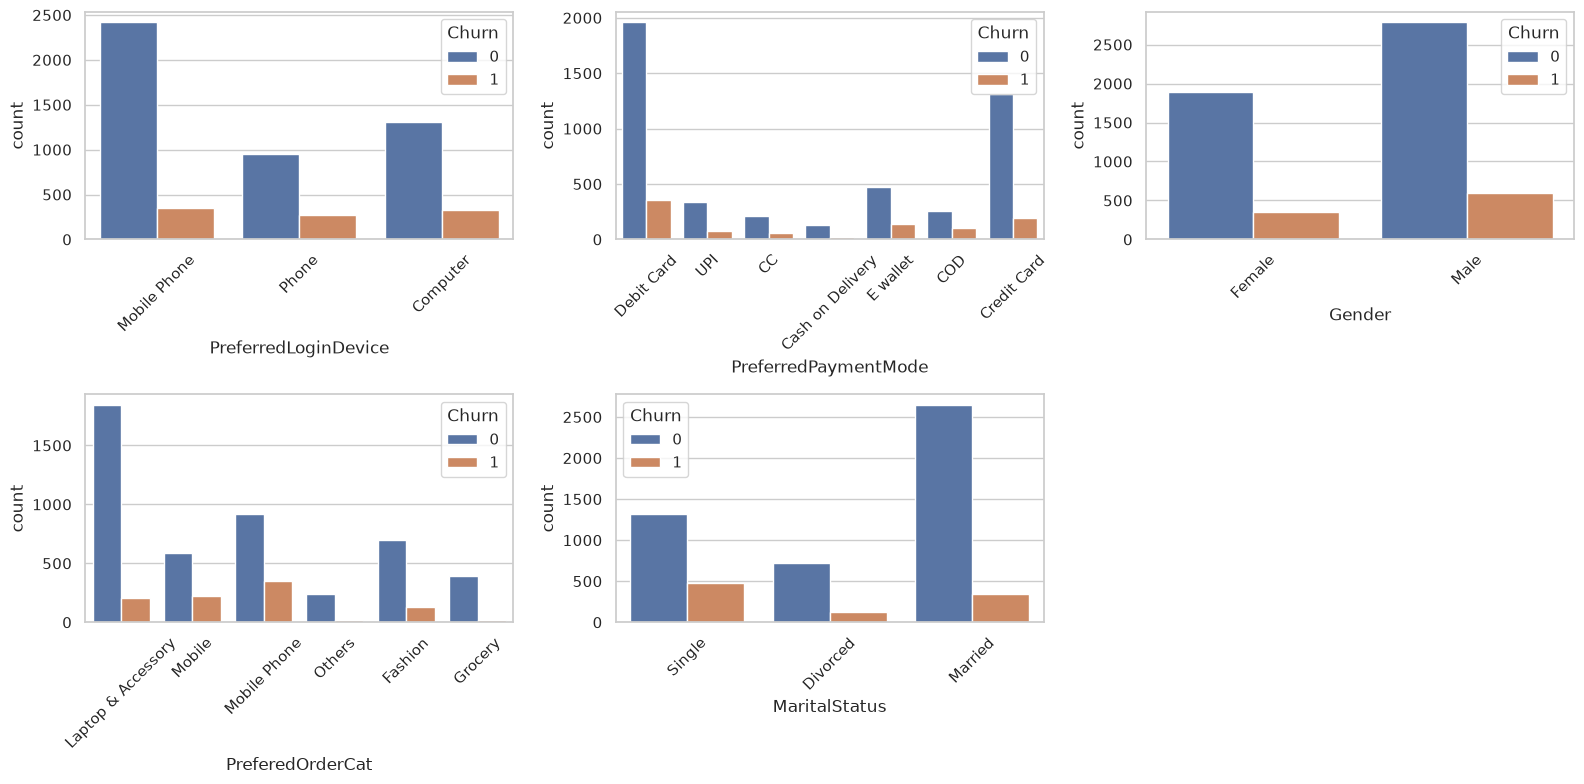

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, categorical_cols):
    sns.countplot(data=df, x=col, hue="Churn", ax=ax)
    ax.tick_params(axis="x", rotation=45)
fig.delaxes(axes.flat[-1])
plt.tight_layout()
plt.show()

## 7. Korelasi Fitur Numerik dengan Target

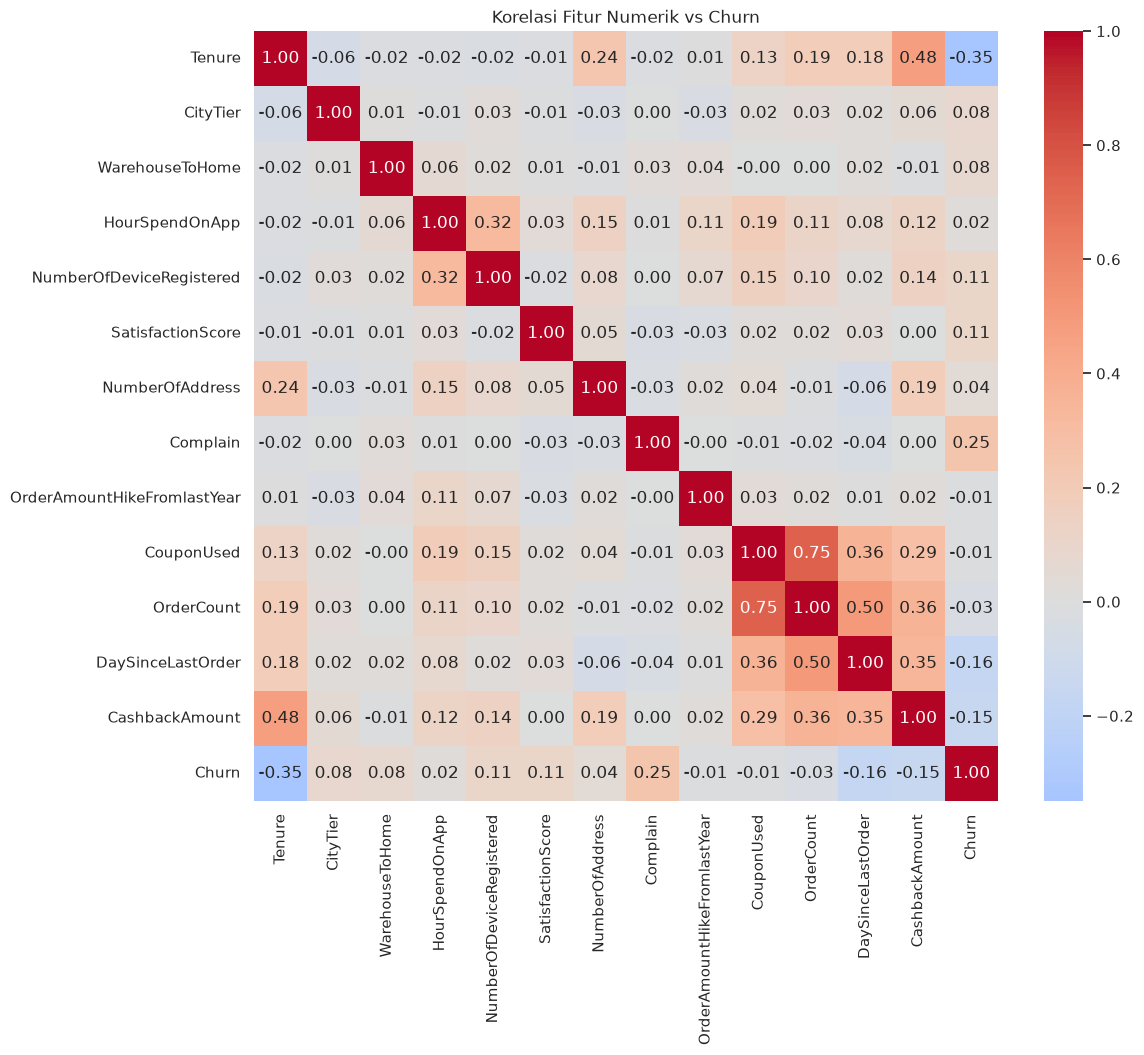

Tenure                        -0.349408
Complain                       0.250188
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
OrderCount                    -0.028697
HourSpendOnApp                 0.018675
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264
Name: Churn, dtype: float64

In [11]:
corr = df[[*numeric_cols, "Churn"]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi Fitur Numerik vs Churn")
plt.show()

corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)

## 8. Ringkasan Insight

- Dataset terdiri dari 5630 baris, 20 kolom, target `Churn` **imbalanced** (~17% churn, ~83% tidak churn).
- 7 kolom numerik punya missing value (masing-masing ~4-5% dari total baris) -> ditangani dengan imputasi median di tahap preprocessing.
- Kolom `CustomerID` hanya identifier, tidak punya nilai prediktif -> dibuang.
- Ditemukan **kategori duplikat** (lihat 6.1): `"CC"`/`"Credit Card"`, `"COD"`/`"Cash on Delivery"` di `PreferredPaymentMode`, dan `"Mobile"`/`"Mobile Phone"` di `PreferedOrderCat` -> digabung lewat `normalize_categories()` sebelum one-hot encoding, supaya sinyal fiturnya tidak terpecah.
- 5 kolom kategorikal (`PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat`, `MaritalStatus`) di-encode (one-hot) setelah normalisasi kategori di atas.
- Karena target imbalanced, evaluasi model sebaiknya tidak hanya mengandalkan accuracy -- precision/recall/F1/ROC-AUC lebih representatif (lihat `metrics.json` hasil `src/train.py`).

Langkah selanjutnya: `src/preprocess.py` (normalisasi kategori, cleaning & splitting) -> `src/train.py` (training model), dijalankan melalui pipeline `dvc.yaml`.

**Hasil setelah perbaikan normalisasi kategori** (dibanding sebelumnya): jumlah kolom fitur turun dari 30 menjadi 27 (kategori duplikat tergabung), dan performa model membaik -- recall naik dari 0.695 menjadi 0.721, F1 dari 0.812 menjadi 0.825, dengan accuracy/precision/ROC-AUC tetap stabil.